# Sentiment Analysis of IMDb Movie Reviews
## Using Simple RNN, LSTM, and LSTM + Word2Vec Embeddings
### Part III: Language Task
---

## Install Dependencies

In [1]:
!pip install wordcloud -q
!pip install gensim -q
print('All packages installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 28.9 MB/s eta 0:00:00
All packages installed.


## Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)
from nltk.corpus import stopwords
from nltk.stem  import WordNetLemmatizer

from wordcloud   import WordCloud
from collections import Counter

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.preprocessing.text     import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models                 import Sequential
from tensorflow.keras.layers                 import Embedding, SimpleRNN, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks              import EarlyStopping

import gensim.downloader as api

print('TensorFlow:', tf.__version__)
print('All libraries loaded successfully!')

TensorFlow: 2.20.0
All libraries loaded successfully!


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Upload & Load Dataset

In [9]:
df_train = pd.read_csv('/content/drive/MyDrive/AI(6)/AI/Collection of Dataset for Text Classification- 2026/5. Movie Review Dataset/train_movie_review.csv')
df_val   = pd.read_csv('/content/drive/MyDrive/AI(6)/AI/Collection of Dataset for Text Classification- 2026/5. Movie Review Dataset/val_movie_review.csv')
df_test  = pd.read_csv('/content/drive/MyDrive/AI(6)/AI/Collection of Dataset for Text Classification- 2026/5. Movie Review Dataset/test_movie_review.csv')

for df in [df_train, df_val, df_test]:
    if 'Unnamed: 0' in df.columns:
        df.drop(columns=['Unnamed: 0'], inplace=True)

print('Columns:', df_train.columns.tolist())
print(f'Train: {df_train.shape}  |  Val: {df_val.shape}  |  Test: {df_test.shape}')
df_train.head(3)

Columns: ['review', 'sentiment']
Train: (35000, 2)  |  Val: (5000, 2)  |  Test: (10000, 2)


,review,sentiment
0,"Having avoided seeing the movie in the cinema,...",0
1,With this movie I was really hoping that the i...,0
2,Raymond Burr stars as an attorney caught up in...,0


## Exploratory Data Analysis

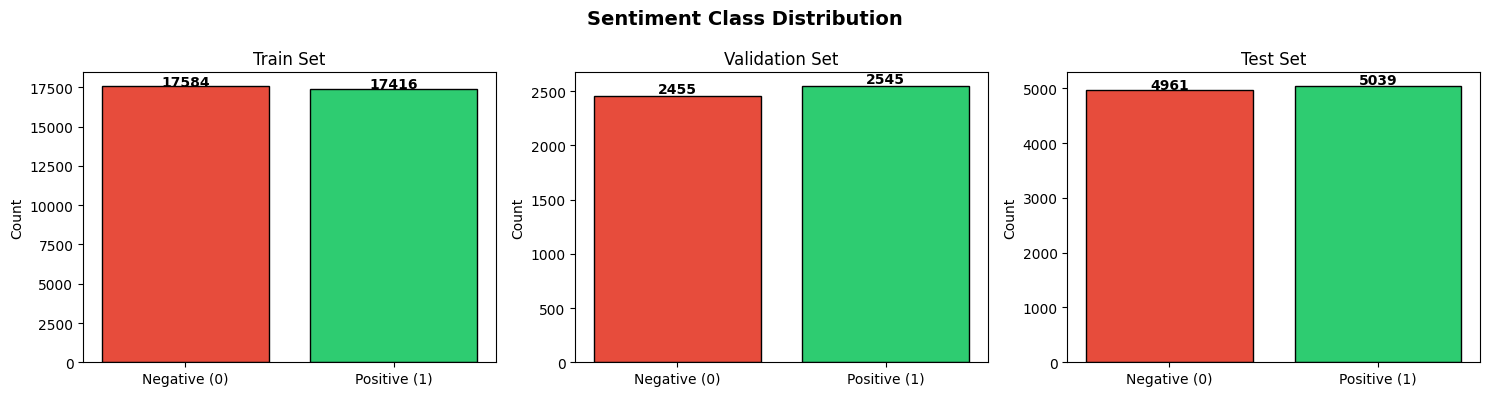

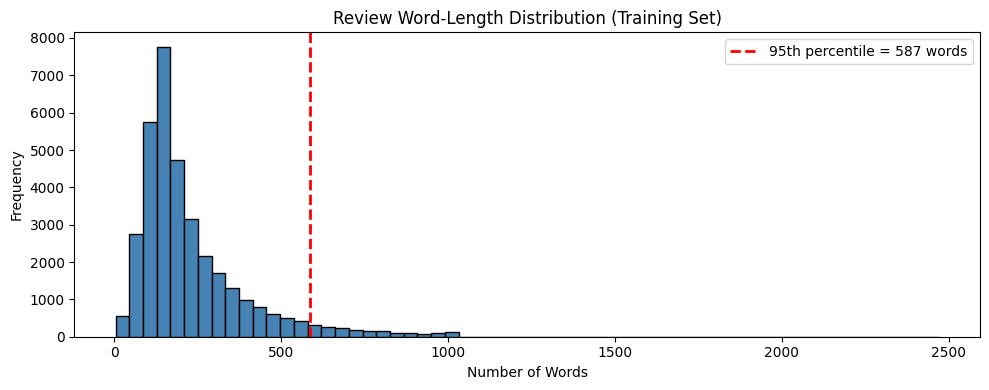

count    35000.000000
mean       230.728714
std        170.956346
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: raw_len, dtype: float64


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (df, title) in zip(axes, [(df_train,'Train'),(df_val,'Validation'),(df_test,'Test')]):
    counts = df['sentiment'].value_counts().sort_index()
    ax.bar(['Negative (0)','Positive (1)'], [counts.get(0,0), counts.get(1,0)],
           color=['#E74C3C','#2ECC71'], edgecolor='black')
    ax.set_title(f'{title} Set')
    ax.set_ylabel('Count')
    for i, v in enumerate([counts.get(0,0), counts.get(1,0)]):
        ax.text(i, v+30, str(v), ha='center', fontweight='bold')
plt.suptitle('Sentiment Class Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

df_train['raw_len'] = df_train['review'].apply(lambda x: len(str(x).split()))
p95 = int(np.percentile(df_train['raw_len'], 95))

plt.figure(figsize=(10, 4))
plt.hist(df_train['raw_len'], bins=60, color='steelblue', edgecolor='black')
plt.axvline(p95, color='red', linestyle='--', linewidth=2,
            label=f'95th percentile = {p95} words')
plt.title('Review Word-Length Distribution (Training Set)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()
print(df_train['raw_len'].describe())

## Text Preprocessing

In [11]:
CONTRACTIONS = {
    "don't":"do not", "doesn't":"does not", "didn't":"did not",
    "won't":"will not", "wouldn't":"would not", "can't":"cannot",
    "couldn't":"could not", "shouldn't":"should not", "isn't":"is not",
    "aren't":"are not", "wasn't":"was not", "weren't":"were not",
    "i'm":"i am", "i've":"i have", "i'll":"i will", "i'd":"i would",
    "it's":"it is", "it'll":"it will", "they're":"they are",
    "they've":"they have", "they'll":"they will", "they'd":"they would",
    "we're":"we are", "we've":"we have", "we'll":"we will",
    "you're":"you are", "you've":"you have", "you'll":"you will",
    "he's":"he is", "she's":"she is", "that's":"that is",
    "there's":"there is", "what's":"what is", "who's":"who is",
    "could've":"could have", "should've":"should have",
    "would've":"would have", "ain't":"is not", "let's":"let us"
}

STOP_WORDS = set(stopwords.words('english'))
# CRITICAL FIX: Remove negation words so 'not bad' stays as 'not bad' not just 'bad'
NEGATION_WORDS = {'no', 'not', 'nor', 'never', 'neither', 'nobody', 'nothing',
                  'nowhere', 'nor', 'hardly', 'scarcely', 'barely', 'without'}
STOP_WORDS -= NEGATION_WORDS

lemmatizer = WordNetLemmatizer()

def expand_contractions(text):
    for c, e in CONTRACTIONS.items():
        text = text.replace(c, e)
    return text

def clean_text(text: str) -> str:
    """
    1. Lowercase  2. Expand contractions  3. Remove URLs
    4. Remove HTML tags  5. Remove @mentions/#hashtags
    6. Remove numbers & special chars  7. Strip whitespace
    8. Remove stopwords (preserving negation)  9. Lemmatize
    """
    text = str(text).lower()
    text = expand_contractions(text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOP_WORDS]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

print('Cleaning training set (35,000 rows — ~1 min)...')
df_train['clean_review'] = df_train['review'].apply(clean_text)
print('Cleaning validation set...')
df_val['clean_review']   = df_val['review'].apply(clean_text)
print('Cleaning test set...')
df_test['clean_review']  = df_test['review'].apply(clean_text)

print('\n--- Before cleaning ---')
print(df_train['review'].iloc[0][:300])
print('\n--- After cleaning ---')
print(df_train['clean_review'].iloc[0][:300])

Cleaning training set (35,000 rows — ~1 min)...
Cleaning validation set...
Cleaning test set...

--- Before cleaning ---
Having avoided seeing the movie in the cinema, but buying the DVD for my wife for Xmas, I had to watch it. I did not expect much, which usually means I get more than I bargained for. But 'Mamma Mia' - utter, utter cr**. I like ABBA, I like the songs, I have the old LPs. But this film is just terribl

--- After cleaning ---
avoided seeing movie cinema buying dvd wife xmas watch not expect much usually mean get bargained mamma mia utter utter cr like abba like song old lp film terrible stage show look like bit musical race along song hurriedly following one another no characterisation dance number heavily choreographed 


## Visualise Cleaned Data

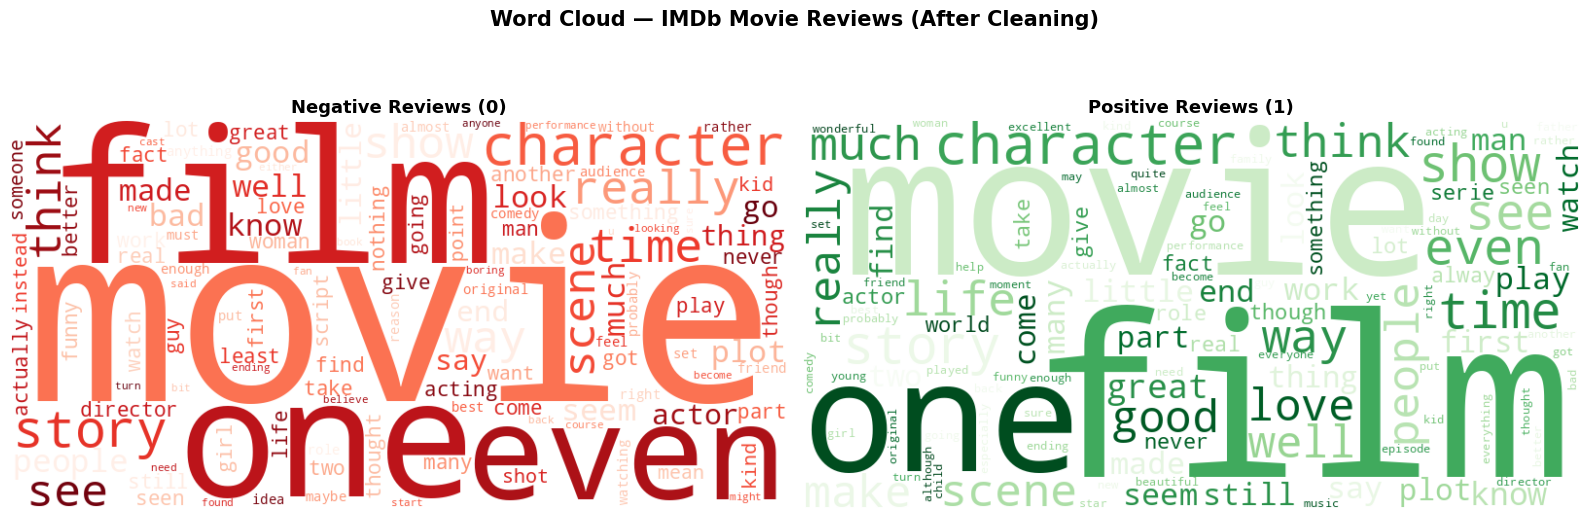

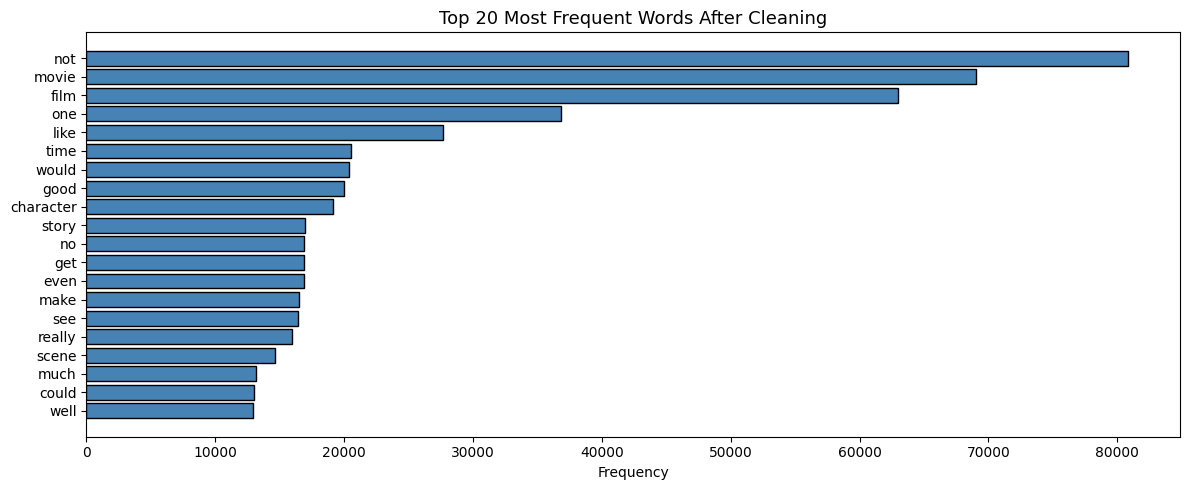

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, label, cmap, title in zip(
        axes, [0, 1], ['Reds', 'Greens'],
        ['Negative Reviews (0)', 'Positive Reviews (1)']):
    corpus = ' '.join(df_train[df_train['sentiment'] == label]['clean_review'])
    wc = WordCloud(width=800, height=400, background_color='white',
                   colormap=cmap, max_words=120).generate(corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold')
plt.suptitle('Word Cloud — IMDb Movie Reviews (After Cleaning)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

all_words = ' '.join(df_train['clean_review']).split()
top20     = Counter(all_words).most_common(20)
words, counts = zip(*top20)

plt.figure(figsize=(12, 5))
plt.barh(list(words)[::-1], list(counts)[::-1], color='steelblue', edgecolor='black')
plt.title('Top 20 Most Frequent Words After Cleaning', fontsize=13)
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()

## Tokenization and Sequence Padding

In [ ]:
VOCAB_SIZE    = 30000   
OOV_TOKEN     = '<OOV>'
EMBEDDING_DIM = 128    
BATCH_SIZE    = 256    
EPOCHS        = 20     

clean_lengths = df_train['clean_review'].apply(lambda x: len(x.split()))
MAX_LEN = int(np.percentile(clean_lengths, 95))
print(f'Padding MAX_LEN (95th percentile): {MAX_LEN} tokens')

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(df_train['clean_review'])
word_index = tokenizer.word_index
print(f'Total unique words: {len(word_index)}')

def to_padded(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')

X_train = to_padded(df_train['clean_review'])
X_val   = to_padded(df_val['clean_review'])
X_test  = to_padded(df_test['clean_review'])

y_train = df_train['sentiment'].values.astype('float32')
y_val   = df_val['sentiment'].values.astype('float32')
y_test  = df_test['sentiment'].values.astype('float32')

print(f'X_train: {X_train.shape}')
print(f'X_val  : {X_val.shape}')
print(f'X_test : {X_test.shape}')
print(f'y_train sample: {y_train[:8]}')

Padding MAX_LEN (95th percentile): 307 tokens
Total unique words: 160113
X_train: (35000, 307)
X_val  : (5000, 307)
X_test : (10000, 307)
y_train sample: [0. 0. 0. 1. 0. 1. 1. 0.]


## Helper Functions

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_accuracy', patience=5,
    restore_best_weights=True, verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy', factor=0.5,
    patience=3, verbose=1, min_lr=1e-6
)

def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[0].set_title(f'{title} — Accuracy')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[1].plot(history.history['loss'],     label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_title(f'{title} — Loss')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

def evaluate_model(model, X, y, label='Test'):
    y_prob = model.predict(X, verbose=0)
    y_pred = (y_prob > 0.5).astype(int).flatten()
    acc    = accuracy_score(y, y_pred)
    print(f'\n{"="*55}')
    print(f'  {label}')
    print(f'  Accuracy: {acc:.4f}  ({acc*100:.2f}%)')
    print(f'{"="*55}')
    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative','Positive'],
                yticklabels=['Negative','Positive'])
    plt.title(f'Confusion Matrix — {label}')
    plt.ylabel('Actual'); plt.xlabel('Predicted')
    plt.tight_layout(); plt.show()
    print(classification_report(y, y_pred, target_names=['Negative','Positive']))
    return acc, y_pred

print('Helper functions and callbacks ready.')

Helper functions and callbacks ready.


## Model 1: Simple RNN with Trainable Embedding

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

tf.keras.backend.clear_session()

rnn_model = Sequential(name='SimpleRNN_Model')
rnn_model.add(Embedding(input_dim=VOCAB_SIZE, output_dim=128))
rnn_model.add(Bidirectional(SimpleRNN(128, return_sequences=True)))
rnn_model.add(Bidirectional(SimpleRNN(64)))
rnn_model.add(Dropout(0.4))
rnn_model.add(Dense(64, activation='relu'))
rnn_model.add(Dropout(0.3))
rnn_model.add(Dense(1, activation='sigmoid'))

rnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

rnn_model.build(input_shape=(None, MAX_LEN))
rnn_model.summary()

Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 307, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 307, 256)       │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,955,201 (15.09 MB)

 Trainable params: 3,955,201 (15.09 MB)

 Non-trainable params: 0 (0.00 B)

Training Model 1 — Bidirectional Simple RNN...
Epoch 1/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 30s 163ms/step - accuracy: 0.5056 - loss: 0.7005 - val_accuracy: 0.4988 - val_loss: 0.6931 - learning_rate: 0.0010
Epoch 2/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 17s 123ms/step - accuracy: 0.5192 - loss: 0.6922 - val_accuracy: 0.6302 - val_loss: 0.6531 - learning_rate: 0.0010
Epoch 3/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 18s 129ms/step - accuracy: 0.6798 - loss: 0.6025 - val_accuracy: 0.7532 - val_loss: 0.5336 - learning_rate: 0.0010
Epoch 4/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 17s 124ms/step - accuracy: 0.7976 - loss: 0.4632 - val_accuracy: 0.7888 - val_loss: 0.4767 - learning_rate: 0.0010
Epoch 5/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 17s 124ms/step - accuracy: 0.8386 - loss: 0.3903 - val_accuracy: 0.7966 - val_loss: 0.5049 - learning_rate: 0.0010
Epoch 6/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 17s 123ms/step - accuracy: 0.7829 - loss: 0.4605 - val_accuracy: 0.6754 - val_loss: 0.6200 - learning_rate: 0.0010
Epoch 7/50
137/137 ━━━━

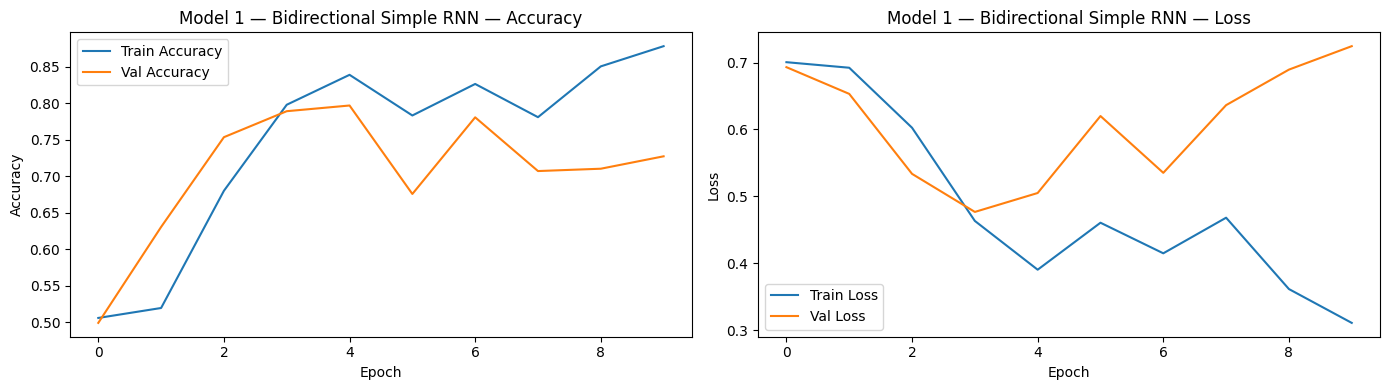

In [ ]:
early_stop_rnn = EarlyStopping(
    monitor='val_accuracy',
    patience=5,           
    restore_best_weights=True,
    verbose=1
)

reduce_lr_rnn = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=3,           
    verbose=1,
    min_lr=1e-7
)

print('Training Model 1 — Bidirectional Simple RNN...')
history_rnn = rnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop_rnn, reduce_lr_rnn],
    verbose=1
)
plot_history(history_rnn, 'Model 1 — Bidirectional Simple RNN')


  Model 1 (Simple RNN) — Test Set
  Accuracy: 0.8016  (80.16%)


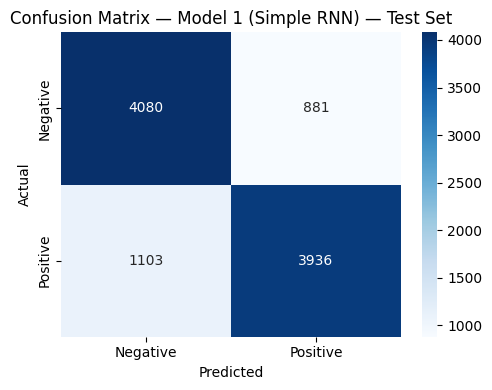

              precision    recall  f1-score   support

    Negative       0.79      0.82      0.80      4961
    Positive       0.82      0.78      0.80      5039

    accuracy                           0.80     10000
   macro avg       0.80      0.80      0.80     10000
weighted avg       0.80      0.80      0.80     10000



In [21]:
acc_rnn, preds_rnn = evaluate_model(rnn_model, X_test, y_test, 'Model 1 (Simple RNN) — Test Set')

## Model 2: LSTM with Trainable Embedding

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

lstm_model = Sequential(name='LSTM_Model')
lstm_model.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM))
lstm_model.add(Bidirectional(LSTM(128, return_sequences=True)))
lstm_model.add(Bidirectional(LSTM(64)))
lstm_model.add(Dropout(0.4))
lstm_model.add(Dense(64, activation='relu'))
lstm_model.add(Dropout(0.3))
lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
lstm_model.build(input_shape=(None, MAX_LEN))
lstm_model.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 307, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 307, 256)       │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,275,841 (16.31 MB)

 Trainable params: 4,275,841 (16.31 MB)

 Non-trainable params: 0 (0.00 B)

Training Model 2 — Bidirectional LSTM...
Epoch 1/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 27s 143ms/step - accuracy: 0.7568 - loss: 0.4759 - val_accuracy: 0.8616 - val_loss: 0.3242 - learning_rate: 0.0010
Epoch 2/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 20s 144ms/step - accuracy: 0.9139 - loss: 0.2310 - val_accuracy: 0.8762 - val_loss: 0.3022 - learning_rate: 0.0010
Epoch 3/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 19s 139ms/step - accuracy: 0.9560 - loss: 0.1339 - val_accuracy: 0.8690 - val_loss: 0.3985 - learning_rate: 0.0010
Epoch 4/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 20s 138ms/step - accuracy: 0.9680 - loss: 0.1003 - val_accuracy: 0.8472 - val_loss: 0.4290 - learning_rate: 0.0010
Epoch 5/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.9657 - loss: 0.1011
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
137/137 ━━━━━━━━━━━━━━━━━━━━ 19s 139ms/step - accuracy: 0.9680 - loss: 0.0961 - val_accuracy: 0.8666 - val_loss: 0.4586 - learning_rate: 0.0010
Epoch 6/50
137/137 ━━━━━━━━━━━━

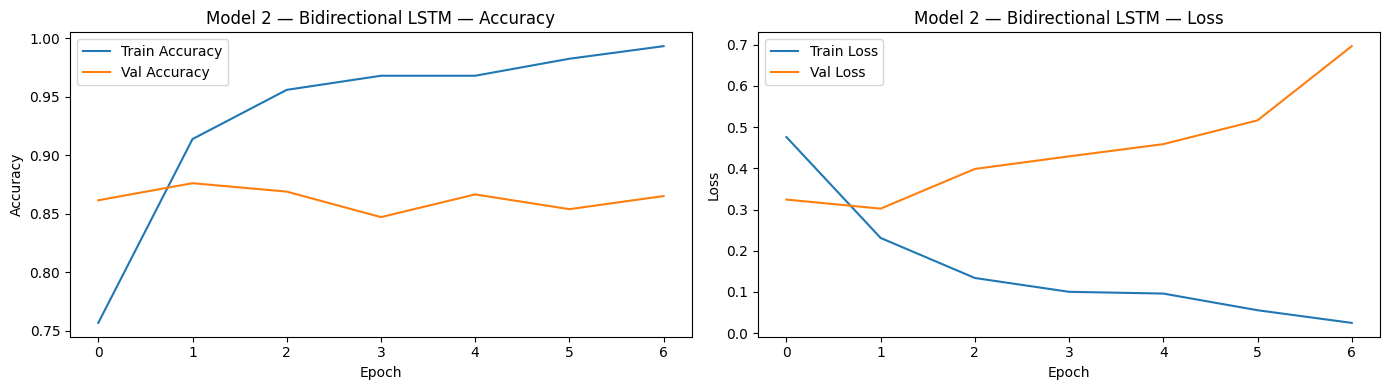

In [23]:
print('Training Model 2 — Bidirectional LSTM...')
history_lstm = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
plot_history(history_lstm, 'Model 2 — Bidirectional LSTM')


  Model 2 (LSTM) — Test Set
  Accuracy: 0.8777  (87.77%)


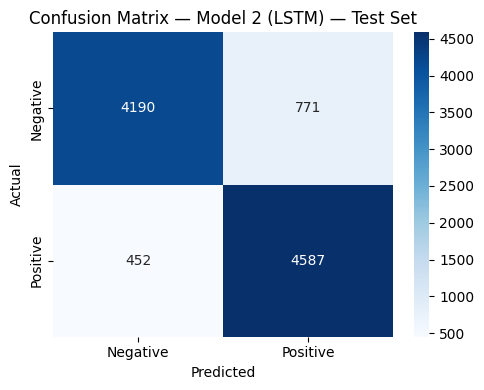

              precision    recall  f1-score   support

    Negative       0.90      0.84      0.87      4961
    Positive       0.86      0.91      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [24]:
acc_lstm, preds_lstm = evaluate_model(lstm_model, X_test, y_test, 'Model 2 (LSTM) — Test Set')

## Model 3: LSTM with Pretrained Word2Vec Embeddings

In [ ]:
print('Downloading Word2Vec embeddings (glove-wiki-gigaword-100, ~128 MB)...')
embedding_model = api.load('glove-wiki-gigaword-100')
EMBED_DIM_W2V   = 100
print('Done!')

embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM_W2V))
found = 0
for word, idx in word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if word in embedding_model:
        embedding_matrix[idx] = embedding_model[word]
        found += 1

coverage = found / min(len(word_index), VOCAB_SIZE) * 100
print(f'Word2Vec coverage: {found}/{min(len(word_index), VOCAB_SIZE)} words ({coverage:.1f}%)')

[==================================================] 100.0% 128.1/128.1MB downloaded
Done!
Word2Vec coverage: 27107/30000 words (90.4%)


In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

# Model 3: Bidirectional LSTM with pretrained Word2Vec embeddings (frozen)
lstm_w2v_model = Sequential(name='LSTM_Word2Vec_Model')
lstm_w2v_model.add(Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBED_DIM_W2V,
    weights=[embedding_matrix],
    trainable=False      
))
lstm_w2v_model.add(Bidirectional(LSTM(128, return_sequences=True)))
lstm_w2v_model.add(Bidirectional(LSTM(64)))
lstm_w2v_model.add(Dropout(0.4))
lstm_w2v_model.add(Dense(64, activation='relu'))
lstm_w2v_model.add(Dropout(0.3))
lstm_w2v_model.add(Dense(1, activation='sigmoid'))

lstm_w2v_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
lstm_w2v_model.build(input_shape=(None, MAX_LEN))
lstm_w2v_model.summary()

Model: "LSTM_Word2Vec_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 307, 100)       │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 307, 256)       │       234,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,407,169 (13.00 MB)

 Trainable params: 407,169 (1.55 MB)

 Non-trainable params: 3,000,000 (11.44 MB)

Training Model 3 — Bidirectional LSTM + Word2Vec...
Epoch 1/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 22s 140ms/step - accuracy: 0.7214 - loss: 0.5572 - val_accuracy: 0.7952 - val_loss: 0.4533 - learning_rate: 0.0010
Epoch 2/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 18s 133ms/step - accuracy: 0.8040 - loss: 0.4409 - val_accuracy: 0.8264 - val_loss: 0.3935 - learning_rate: 0.0010
Epoch 3/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.8233 - loss: 0.4074
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
137/137 ━━━━━━━━━━━━━━━━━━━━ 18s 130ms/step - accuracy: 0.8265 - loss: 0.4019 - val_accuracy: 0.8238 - val_loss: 0.3948 - learning_rate: 0.0010
Epoch 4/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 18s 130ms/step - accuracy: 0.8399 - loss: 0.3741 - val_accuracy: 0.8316 - val_loss: 0.3847 - learning_rate: 5.0000e-04
Epoch 5/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 18s 130ms/step - accuracy: 0.8548 - loss: 0.3500 - val_accuracy: 0.8518 - val_loss: 0.3444 - learning_rate: 5.0000e-04
Epoch 5: ear

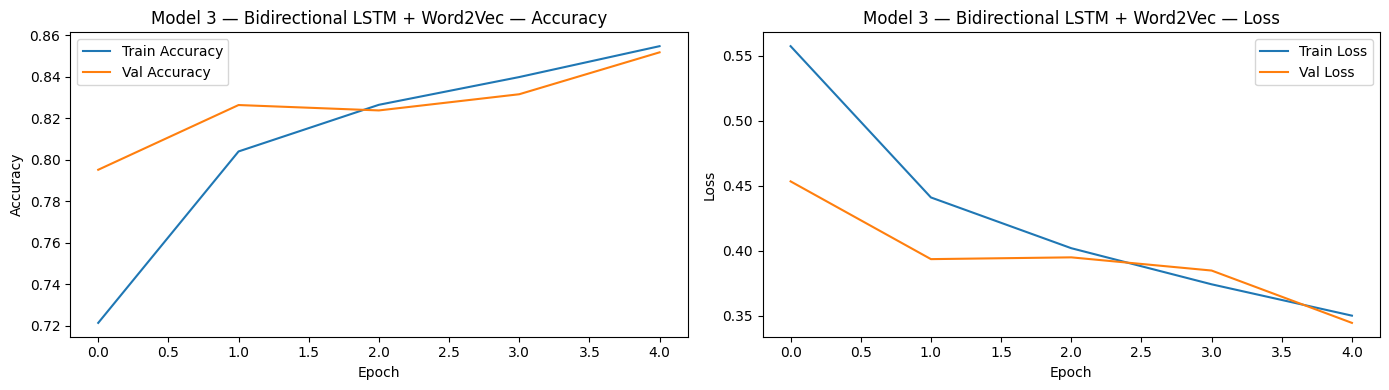

In [27]:
print('Training Model 3 — Bidirectional LSTM + Word2Vec...')
history_w2v = lstm_w2v_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
plot_history(history_w2v, 'Model 3 — Bidirectional LSTM + Word2Vec')


  Model 3 (LSTM + Word2Vec) — Test Set
  Accuracy: 0.7969  (79.69%)


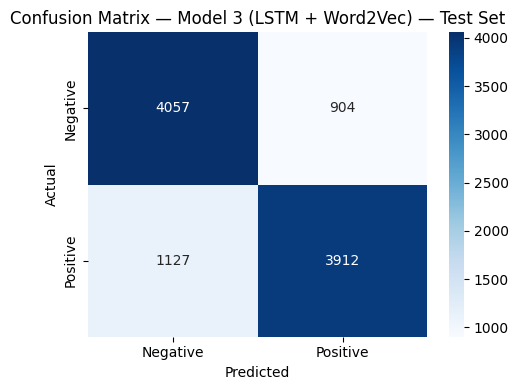

              precision    recall  f1-score   support

    Negative       0.78      0.82      0.80      4961
    Positive       0.81      0.78      0.79      5039

    accuracy                           0.80     10000
   macro avg       0.80      0.80      0.80     10000
weighted avg       0.80      0.80      0.80     10000



In [28]:
acc_w2v, preds_w2v = evaluate_model(lstm_w2v_model, X_test, y_test, 'Model 3 (LSTM + Word2Vec) — Test Set')

## Model Comparison

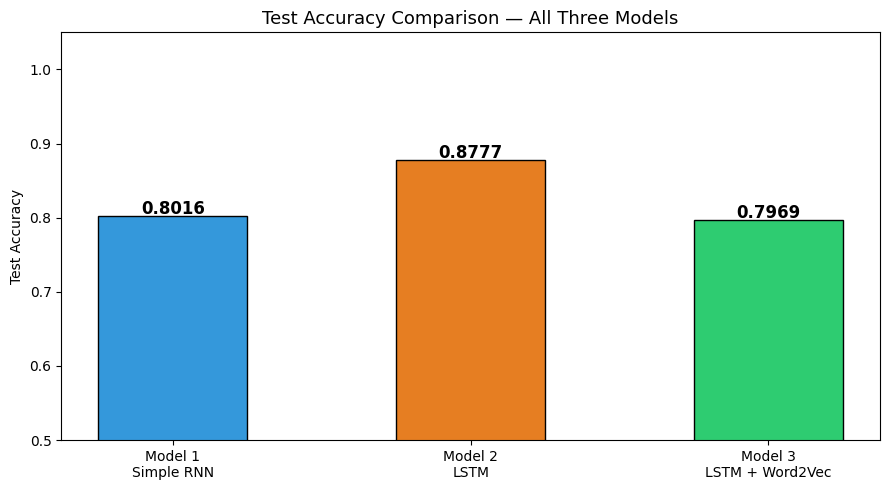

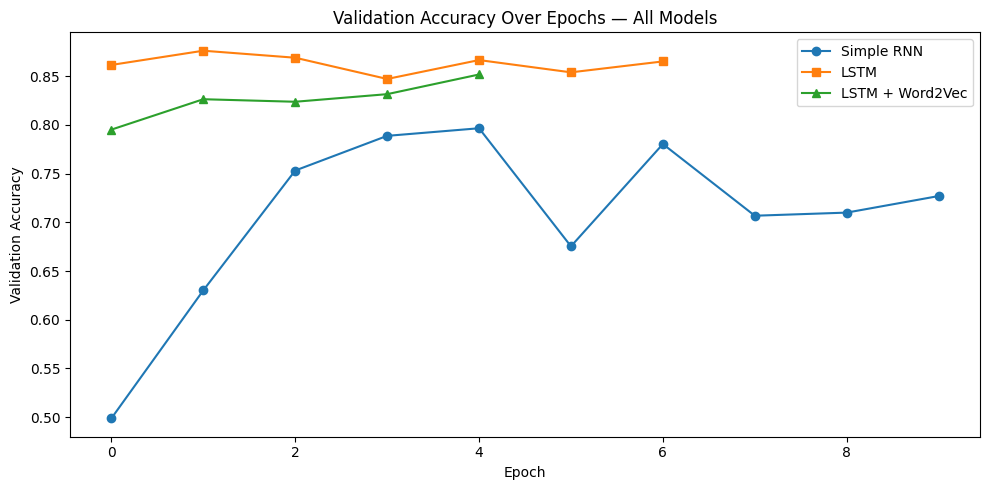

          Model                        Embedding Test Accuracy
     Simple RNN              Trainable (128-dim)        0.8016
           LSTM              Trainable (128-dim)        0.8777
LSTM + Word2Vec Pretrained Word2Vec-100 (frozen)        0.7969


In [29]:
model_names = ['Model 1\nSimple RNN', 'Model 2\nLSTM', 'Model 3\nLSTM + Word2Vec']
acc_scores  = [acc_rnn, acc_lstm, acc_w2v]
colors      = ['#3498DB', '#E67E22', '#2ECC71']

plt.figure(figsize=(9, 5))
bars = plt.bar(model_names, acc_scores, color=colors, width=0.5, edgecolor='black')
for bar, score in zip(bars, acc_scores):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.003,
             f'{score:.4f}', ha='center', fontweight='bold', fontsize=12)
plt.title('Test Accuracy Comparison — All Three Models', fontsize=13)
plt.ylabel('Test Accuracy')
plt.ylim(0.5, 1.05)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_rnn.history['val_accuracy'],  marker='o', label='Simple RNN')
plt.plot(history_lstm.history['val_accuracy'], marker='s', label='LSTM')
plt.plot(history_w2v.history['val_accuracy'],  marker='^', label='LSTM + Word2Vec')
plt.title('Validation Accuracy Over Epochs — All Models')
plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy')
plt.legend(); plt.tight_layout(); plt.show()

summary_df = pd.DataFrame({
    'Model'        : ['Simple RNN', 'LSTM', 'LSTM + Word2Vec'],
    'Embedding'    : ['Trainable (128-dim)', 'Trainable (128-dim)', 'Pretrained Word2Vec-100 (frozen)'],
    'Test Accuracy': [f'{a:.4f}' for a in acc_scores]
})
print(summary_df.to_string(index=False))

##Error Analysis



In [30]:
# Use best model (change to preds_w2v if Model 3 performed better)
best_preds = preds_lstm
best_label = 'Model 2 (LSTM)'

df_results = df_test.copy().reset_index(drop=True)
df_results['predicted'] = best_preds
df_results['correct']   = (df_results['sentiment'] == df_results['predicted'])

df_errors = df_results[~df_results['correct']]
print(f'Misclassified by {best_label}: {len(df_errors)}/{len(df_results)} '
      f'({len(df_errors)/len(df_results)*100:.1f}%)')

print('\n' + '='*65)
print('  SAMPLE MISCLASSIFIED EXAMPLES')
print('='*65)
for _, row in df_errors.sample(3, random_state=42).iterrows():
    true_lbl = 'Positive' if row['sentiment'] == 1 else 'Negative'
    pred_lbl = 'Positive' if row['predicted'] == 1 else 'Negative'
    print(f'\nReview   : {str(row["review"])[:350]}')
    print(f'True     : {true_lbl}')
    print(f'Predicted: {pred_lbl}')
    print('-'*65)

print("""
ANALYSIS OF ERRORS
==================
1. Sarcasm/Irony: Model cannot detect phrases like 'brilliant
   acting... for a comedy' where positive words carry negative intent.

2. Long-range context loss: Reviews with mixed sentiment across
   hundreds of words are hard for RNN/LSTM to capture fully even
   with Bidirectional layers.

3. OOV words: Niche film terminology not covered by GloVe
   is mapped to zeros, losing semantic meaning.

4. Subtle sentiment: Reviews with moderate language (e.g., 'it was
   okay but nothing special') are harder to classify correctly.

SUGGESTED IMPROVEMENTS
=======================
- Use Transformer models (DistilBERT) for richer contextual embeddings.
- Fine-tune GloVe embeddings (trainable=True) after warm-up epochs.
- Use attention mechanisms to focus on the most sentiment-rich words.
- Increase VOCAB_SIZE or use subword tokenization (BPE) for OOV.
- Data augmentation to expose the model to more varied sentence structures.
""")

Misclassified by Model 2 (LSTM): 1223/10000 (12.2%)

  SAMPLE MISCLASSIFIED EXAMPLES

Review   : I don't know what it is with these Brady kids. First, Barry Williams publicly brags about having sexy with his TV sister, Maureen McCormick, then about dating his TV mom, Florence Hederson. Then, Susan (Cindy) Olsen does music for a bunch of porno movies. Then Mike (Bobby) Lookinland gets in trouble for drunk driving. Finally, Maureen (Marcia) McCo
True     : Negative
Predicted: Positive
-----------------------------------------------------------------

Review   : The funniest scene of this movie is probably when our saviours get their medals and plaques and whatnot. So the basic idea is, the police outnumbers these gangsters by like a million to one, but they're powerless because the villains' guns are just a bit bigger. I guess police ammo just kinda bounces of. They decided to shoot this movie in document
True     : Negative
Predicted: Positive
-------------------------------------------

## (EXTRA CREDIT) Real-Time Prediction GUI using Gradio

In [31]:
!pip install gradio -q
import gradio as gr

def predict_sentiment(review_text: str, model_choice: str) -> str:
    if not review_text.strip():
        return 'Please enter a review.'

    cleaned  = clean_text(review_text)
    sequence = tokenizer.texts_to_sequences([cleaned])
    padded   = pad_sequences(sequence, maxlen=MAX_LEN, padding='post', truncating='post')

    model_map = {
        'Model 1 — Simple RNN'      : rnn_model,
        'Model 2 — LSTM'            : lstm_model,
        'Model 3 — LSTM + Word2Vec' : lstm_w2v_model,
    }

    selected = model_map.get(model_choice, lstm_model)
    prob     = float(selected.predict(padded, verbose=0)[0][0])
    label    = 'POSITIVE' if prob >= 0.5 else 'NEGATIVE'
    conf     = prob if prob >= 0.5 else 1 - prob
    return f'{label}\nConfidence: {conf*100:.1f}%'

with gr.Blocks(title='IMDb Sentiment Analyser') as demo:
    gr.Markdown('## IMDb Movie Review Sentiment Analyser')
    gr.Markdown('Trained on 35,000 IMDb reviews. Select a model then enter any review.')

    with gr.Row():
        text_input  = gr.Textbox(lines=6,
                                  placeholder='Paste any IMDb movie review here...',
                                  label='Movie Review')
        model_radio = gr.Radio(
                          choices=['Model 1 — Simple RNN',
                                   'Model 2 — LSTM',
                                   'Model 3 — LSTM + Word2Vec'],
                          value='Model 2 — LSTM',
                          label='Select Model')

    submit_btn = gr.Button('Predict', variant='primary')
    output_box = gr.Textbox(label='Sentiment Prediction')

    submit_btn.click(fn=predict_sentiment,
                     inputs=[text_input, model_radio],
                     outputs=output_box)

    gr.Examples(
        examples=[
            ['This film was absolutely amazing! The acting was superb and the plot kept me on edge throughout.'],
            ['Terrible movie. Complete waste of time and money. The story made absolutely no sense whatsoever.'],
            ['It was okay. Some parts were interesting but overall it felt too long and slow.'],
        ],
        inputs=[text_input],
    )

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://bf11427e3fb45c0af6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
